In [16]:
import numpy as np
import os, sys
from pathlib import Path
import subprocess as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from stl import mesh  # only needed for debug/stl previewing

import apply_transformation_matrix as atm

In [ ]:
# Change the following to your local installation of FreeCAD - the location below is typical for most Windows installations
freecadcmd_exe = r"E:\FreeCAD_1\bin\freecadcmd.exe"

if os.path.isfile(r"bead_0_calibrated.xyz"):
    os.remove(r"bead_0_calibrated.xyz")


In [ ]:

# begin declaration of helper functions
def in_poly(poly, pnts):
    '''
    Convenience function for matplotlib's contains_points, returning a boolean array corresponding to pnts being inside poly as True.
    '''
    from matplotlib import path
    p = path.Path(poly[:, :2])
    return p.contains_points(pnts[:, :2])


def get_svd_orientation(points):
    '''
    Returns a 3x3 rotation matrix required to take z component of the orthonormal matrix of points to either 0,0,1 or 0,0,-1 at the centroid of points, depending on concavity.
    '''
    # get singular vectors, v, with an origin of the centroid of points
    _, _, v = np.linalg.svd(points - np.mean(points, axis=0))
    # normal of plane of best fit is the right singular vector
    normal = v[2]

    # handles the case if the dataset is net convex vs. concave relative to +z
    if normal[2] < 0:
        target = np.array([0, 0, -1])
    else:
        target = np.array([0, 0, 1])

    # solve for angle and axis between normal and target
    angle = np.arccos(np.dot(target, normal))
    axis = np.cross(target, normal)
    axis = axis / np.linalg.norm(axis)  # normalize

    # convenience variables for the rotation matrix
    c = np.cos(angle)
    s = np.sin(angle)
    t = 1 - c
    ux = axis[0]
    uy = axis[1]
    uz = axis[2]

    R = np.array([[c + ux ** 2 * t, ux * uy * t - uz * s, ux * uz * t + uy * s],
                  [uy * ux * t + uz * s, c + uy ** 2 * t, uy * uz * t - ux * s],
                  [uz * ux * t - uy * s, uz * uy * t + ux * s, c + uz ** 2 * t]])

    # return the inverted rotation matrix
    return np.linalg.inv(R)


def do_transform(points, T):
    '''
    Applies 4x4 transformation matrix to points and returns the result
    @Param - points, Nx3 matrix of points; T - 4x4 homologous matrix
    '''
    X = points.copy()
    X = X.transpose()
    X = np.append(X, np.ones((1, X.shape[1])), axis=0)  # pad with 1's
    X = T @ X  # apply by matrix multiplication
    return X[0:3].transpose()  # return an Nx3


def reduce_pnts(pnts, val=10000):
    '''
    returns an index of reduced points based on params pnts and val
    which is the number of points to retain
    '''
    localind = np.arange(0, len(pnts), 1, dtype=int)
    ind = localind[np.arange(0, len(localind), int(len(localind) / val), dtype=int)]
    return ind


def get_trans_from_euler_angles(ax=0, ay=0, az=0):
    '''
    Based on incoming arguments in *radians*, return a 4x4 transformation matrix
    '''

    Rx = np.array([[1, 0, 0], [0, np.cos(ax), -np.sin(ax)], [0, np.sin(ax), np.cos(ax)]])
    Ry = np.array([[np.cos(ay), 0, np.sin(ay)], [0, 1, 0], [-np.sin(ay), 0, np.cos(ay)]])
    Rz = np.array([[np.cos(az), -np.sin(az), 0], [np.sin(az), np.cos(az), 0], [0, 0, 1]])
    R = Rx @ Ry @ Rz

    trans = np.identity(4)
    trans[0:3, 0:3] = R
    return trans

# end of convenience functions

Processed bead_0_no_transformation_sampled.xyz -> bead_0_no_transformation_sampled.xyz


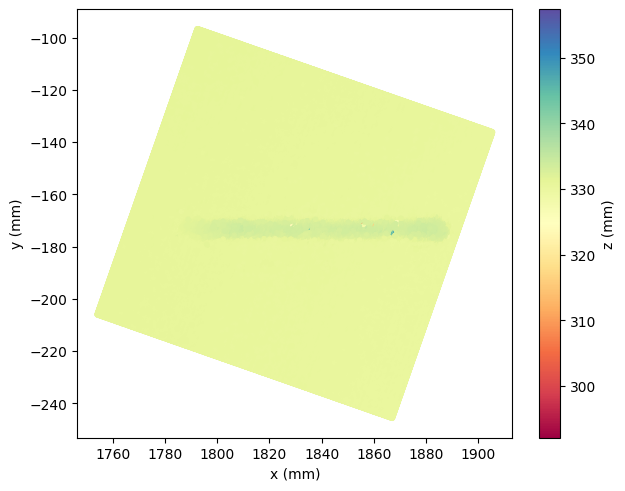

In [19]:
# step one: 'raw' points and apply the transformation matrix that corrects the scanner misorientation
xyz_file_name = atm.main()
raw = np.loadtxt(xyz_file_name)

corr_trans = np.eye(4)
# remoced transformation as has been pre transformed by Jin
# R = np.loadtxt('transformation_matrix.txt') #which is a 3x3
# corr_trans[0:3,0:3] = R
# raw = do_transform(raw,corr_trans)

fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(raw[:, 0], raw[:, 1], c=raw[:, 2], marker='.', cmap="Spectral")  # xy
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
fig.savefig('1_raw.png', dpi=fig.dpi)
plt.show()

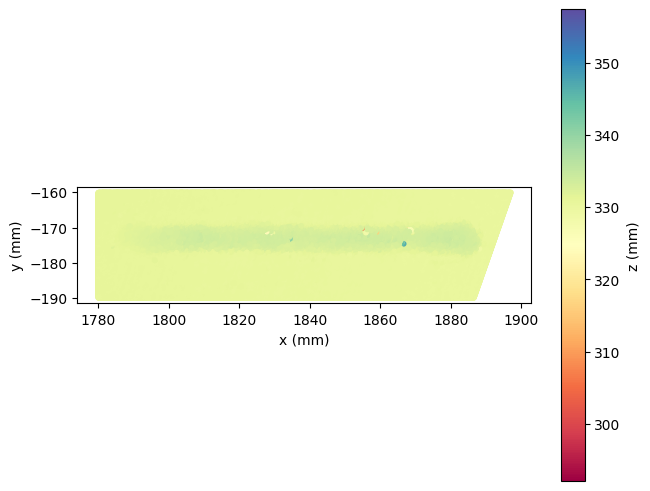

In [21]:
# step two: crop with bounding box (bb) - bounding box based on plotting the overall points and selecting from the previous plot
bb_x = np.array([1780, 1780, 1900, 1900]) 
bb_y = np.array([-190, -160, -160,  -190])
bb = np.array([[bb_x[0], bb_y[0]], [bb_x[1], bb_y[1]], [bb_x[2], bb_y[2]], [bb_x[3], bb_y[3]], [bb_x[0], bb_y[0]]])
f = raw[in_poly(bb, raw), :]
#f jove
height_filter = 250
f = f[(f[:, 2] > height_filter), :]

fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(f[:, 0], f[:, 1], c=f[:, 2], marker='.', cmap="Spectral")  # xy
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
plt.show()

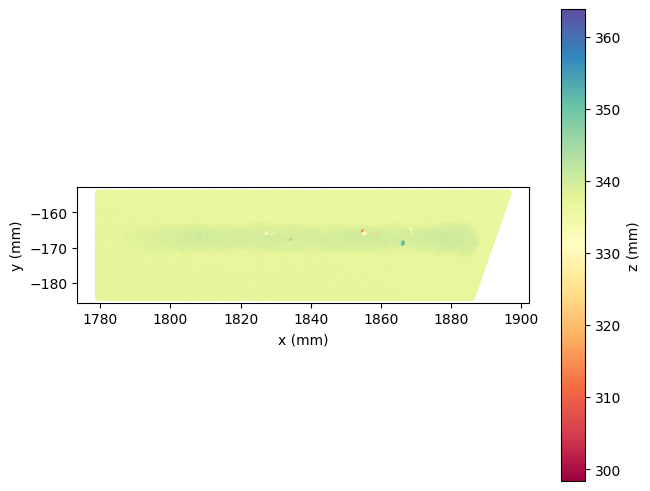

In [22]:
# step three: align svd axis with z, reduce_pnts required to not overload svd routine

R = get_svd_orientation(f[reduce_pnts(f)])
# apply alignment rotation
trans = np.eye(4)
trans[0:3, 0:3] = R
f = do_transform(f, trans)
# clean of the extremes in the data
f = f[(f[:, 2] > 100), :]

fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(f[:, 0], f[:, 1], c=f[:, 2], marker='.', cmap="Spectral")  # xy
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
fig.savefig('3_leveled.png', dpi=fig.dpi)
plt.show()

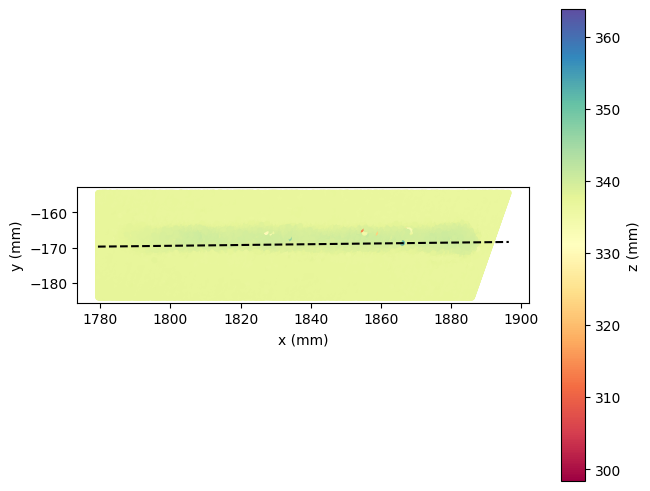

In [24]:
# step four: get points to solve for bead orientation, bead threshold also selected from plotting
#thershold jove
Bead_threshold = 109
bp = f[(f[:, 2] > Bead_threshold), :]

# fit x,y bp to linear expression
coeff = np.polyfit(bp[:, 0], bp[:, 1], 1)
x = np.linspace(np.min(f[:, 0]), np.max(f[:, 0]))  # for plotting
fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(bp[:, 0], bp[:, 1], c=bp[:, 2], marker='.', cmap="Spectral")  # xy
axes.plot(x, x * coeff[0] + coeff[1], 'k--')  # debug
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
fig.savefig('4_bead_orientation.png', dpi=fig.dpi)
plt.show()

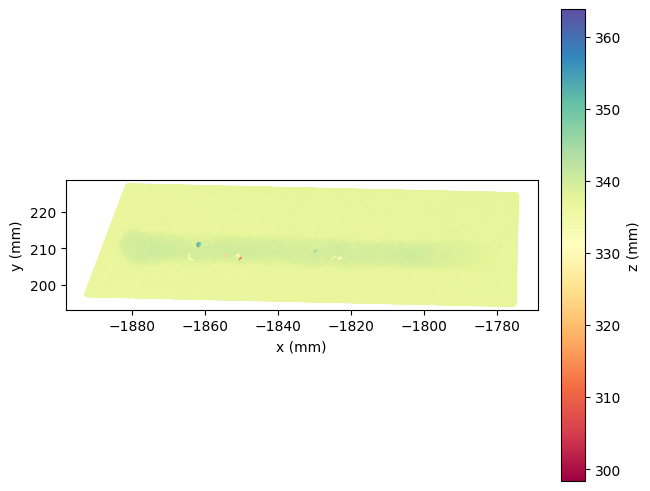

In [26]:
# step five: rotate bead so that it is parallel to the y axis

alpha = -np.arctan(coeff[0]) + np.pi / 2  # alpha returns to the x axis, with an additional cw 90°
rotate_xy = get_trans_from_euler_angles(0, 0, alpha)
f = do_transform(f, rotate_xy)
# update transformation matrix (post multiplication)
trans = trans @ rotate_xy

fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(f[:, 0], f[:, 1], c=f[:, 2], marker='.', cmap="Spectral")  # xy
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
fig.savefig('5_vertical.png', dpi=fig.dpi)
plt.show()

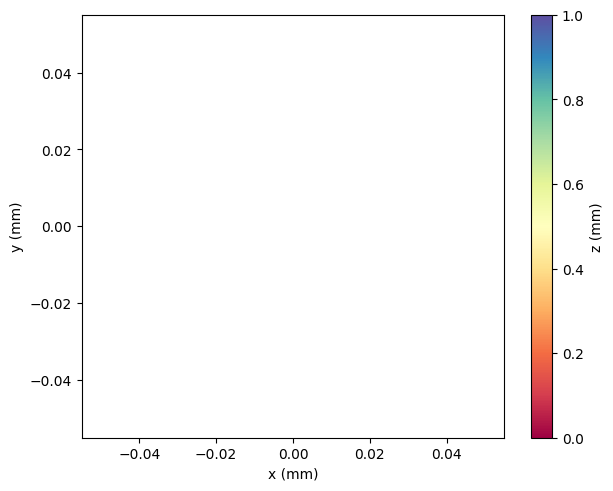

In [31]:
# step six: crop with bounding box again - bounding box based on plotting the overall points and selecting from plot

#bb for jove
bb2_x = np.array([200, 200, 180, 180]) 
bb2_y = np.array([1780, 1900, 1900, 1780])
bb = np.array([[bb2_x[0], bb2_y[0]], [bb2_x[1], bb2_y[1]], [bb2_x[2], bb2_y[2]], [bb2_x[3], bb2_y[3]], [bb2_x[0], bb2_y[0]]])

ff = f[in_poly(bb, f), :]

fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(ff[:, 0], ff[:, 1], c=ff[:, 2], marker='.', cmap="Spectral")  # xy
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
fig.savefig('6_crop2.png', dpi=fig.dpi)
plt.show()

In [32]:
# step seven: perform bead fitting
# get mean plate height and max plate height
print('step 7')
height = np.mean(f[~in_poly(bb, f), 2])
height_max = np.max(f[~in_poly(bb, f), 2])

# get the centroid
cent = np.mean(f, axis=0)

# get a slice of the bead 'seg_t' thick centered on the centroid
seg_t = 0.2
mask = np.logical_and(ff[:, 1] < (cent[1] + seg_t), ff[:, 1] > (cent[1] - seg_t))
x_sec = ff[mask, :]

# array of x values over the width of the domain for plotting
sl_x = np.linspace(np.min(x_sec[:, 0]), np.max(x_sec[:, 0]))

p, _ = find_peaks(x_sec[:, 2], prominence=1)  # to provide guess initialize h,k for fitting parabola


def func(x, a, h, k, level_z):
    '''
    Description of a piecewise/capped parabola of the form y = max(a*(x-h)**2 + k, level_z)
    '''
    y = np.zeros_like(x)
    for i in range(len(x)):
        y[i] = np.max(np.append(a * (x[i] - h) ** 2 + k, level_z))
    return y


# perform curve fit with locked height with an initial guess of a=-0.5, h & k equal to the peaks
popt, _ = curve_fit(lambda x, a, h, k: func(x, a, h, k, height), x_sec[:, 0], x_sec[:, 2],
                    p0=np.array([-0.5, x_sec[p[0], 0], x_sec[p[0], 2]]))

np.savetxt('popt.txt', popt)
fit = func(sl_x, *popt, height)  # result of the fit
print('popt', popt)
print('fit')
print(sl_x)
#print(fit)
np.savetxt('X_fit_Values.txt', sl_x)
np.savetxt('Y_fit_values.txt', fit)
print('end fit')

# get width in x of bead, will run between inter_x[0] to inter_x[1]
p_ = [popt[0], -2 * popt[0] * popt[1],
      popt[0] * popt[1] ** 2 + popt[2]]  # standard representation of vertex representation above
inter_x = np.roots(np.asarray(p_) - np.asarray([0, 0, height]))
print('INTER x', inter_x)
# inter_y = np.polyval(p_, inter_x) #debug


fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(x_sec[:, 0], x_sec[:, 2], c=x_sec[:, 2], marker='.', cmap="Spectral")  # xz
axes.plot(x_sec[p, 0], x_sec[p, 2], 'ro', label='Peak')
axes.plot(popt[1], popt[2] + (1 / (4 * popt[0])), 'k+', label='Focus')
axes.plot(popt[1], popt[2], 'ko', label='Vertex')
axes.plot(sl_x, fit, 'g--', label='Capped fit')
axes.plot(inter_x, [height, height], 'go')
axes.set_aspect('equal')
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
fig.savefig('7_mid_fit.png', dpi=fig.dpi)
plt.show()

step 7


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
# step eight - find the extents of the bead using the maximum height of the plate
h_thres = height_max
bp = ff[(ff[:, 2] > h_thres), :]

y_s, y_e = np.max(bp[:, 1]), np.min(bp[:, 1])
x = np.linspace(inter_x[0], inter_x[1])  # for plotting
y = np.linspace(y_s, y_e)  # for plotting

# get x,y extents of bead
start_xy = np.column_stack((x, (popt[0] * (x - popt[1]) ** 2 + y_s), np.ones(len(x)) * height))
print(start_xy)
end_xy = np.column_stack((np.flip(x), (-popt[0] * (x - popt[1]) ** 2 + y_e), np.ones(len(x)) * height))
print(end_xy)
xy_outline = np.vstack((start_xy, end_xy, start_xy[0, :]))

# add endcap hoops
start_xz = np.column_stack((x, np.ones(len(x)) * start_xy[0, 1], np.polyval(p_, x)))
end_xz = np.column_stack((x, np.ones(len(x)) * end_xy[0, 1], np.polyval(p_, x)))


fig, axes = plt.subplots(constrained_layout=True)
sc = axes.scatter(ff[:, 0], ff[:, 1], c=ff[:, 2], marker='.', cmap="Spectral")  # xy

axes.plot(xy_outline[:, 0], xy_outline[:, 1], 'b--')
axes.plot(start_xz[:, 0], start_xz[:, 1], 'b-')
axes.plot(end_xz[:, 0], end_xz[:, 1], 'b-')
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(sc, label="z (mm)")
axes.set_aspect('equal')
fig.savefig('8_ideal_fit.png', dpi=fig.dpi)
plt.show()


In [ ]:
# step 9 - translate the domain to the focus of the parabola corresponding to the 'start' position
target = np.array([popt[1], start_xy[0, 1], popt[2] + (1 / (4 * popt[0]))])
translate = np.eye(4)
translate[0:3, -1] = -target
# update h,k values in popt, height, y pad end value, inter_x values
inter_x = inter_x - popt[1]
height = height - (popt[2] + (1 / (4 * popt[0])))
y_e = end_xy[0, 1] - start_xy[0, 1]
popt[1], popt[2] = 0, -1 / (4 * popt[0])

print(y_e, 'y_e')
ff = do_transform(ff, translate)
# update transformation matrix (post multiplication)
trans = trans @ translate

# get the centroid
cent = np.mean(ff, axis=0)

# get a slice of the bead 'seg_t' thick centered on the centroid
seg_t = 0.2
mask = np.logical_and(ff[:, 1] < (cent[1] + seg_t), ff[:, 1] > (cent[1] - seg_t))
x_sec = ff[mask, :]

x = np.linspace(inter_x[0], inter_x[1])
p_ = [popt[0], -2 * popt[0] * popt[1], popt[0] * popt[1] ** 2 + popt[2]]
start_xz = np.column_stack((x, np.zeros(len(x)), np.polyval(p_, x)))

fig, axes = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
axes[0].scatter(x_sec[:, 0], x_sec[:, 2], c=x_sec[:, 2], marker='.', cmap="Spectral")  # xz
axes[0].plot(start_xz[:, 0], start_xz[:, 2], 'b-')
sc = axes[1].scatter(ff[:, 0], ff[:, 1], c=ff[:, 2], marker='.', cmap="Spectral")  # xy
axes[1].plot(start_xz[:, 0], start_xz[:, 1], 'b-')
axes[1].plot([0, 0], [0, y_e], 'k+')
plt.colorbar(sc, label="z (mm)")
axes[0].set_aspect('equal')
axes[1].set_aspect('equal')
fig.savefig('9_trans_to_start.png', dpi=fig.dpi)
plt.show()
def gen_fc_bead(inter_x, y_e, popt, plate_params, trans, outfile, freecadcmd_exe):
    print('making freecad macro')
    '''
    Generates a FreeCAD macro and then runs it with freecadcmd to produce geometry files according to the above
    Params:
    inter_x: a list of the x minor and x major values of the bead
    y_e: y extent of bead which assumes bead runs from y positive to y negative
    popt: parabola parameters; a list of the values of a, h, k corresponding to vertex notation
    plate_params: list of plate values: offset from start value in x then y and then plate thickness
    trans: numpy array containing cumulative 4x4 transformation matrix from raw file to orthogonalized
    outfile: path for FreeCAD script
    Output:
    STEP214 and STL file with the same prefix as outfile generated with default settings in the local directory
    '''

    fid = open(outfile, 'wb+')
    fid.write(str.encode('import FreeCAD, Part, Sketcher\nimport Mesh\nimport ObjectsFem\nimport Fem\n'))
    s1 = """
App.newDocument()
App.getDocument('Unnamed').addObject('PartDesign::Body','Body')
App.getDocument('Unnamed').getObject('Body').newObject('Sketcher::SketchObject','Sketch')
App.getDocument('Unnamed').getObject('Sketch').AttachmentSupport = (App.getDocument('Unnamed').getObject('XZ_Plane'),[''])
App.getDocument('Unnamed').getObject('Sketch').MapMode = 'FlatFace'

"""

    p_ = [popt[0], -2 * popt[0] * popt[1], popt[0] * popt[1] ** 2 + popt[2]]
    inter_y = np.polyval(p_, inter_x[1])

    fid.write(str.encode(s1))
    para_str = """
p = Part.Parabola(App.Vector(0,0,0),App.Vector(0,%f,0),App.Vector(0,0,1))
inter_x = %f
inter_y = %f
App.getDocument('Unnamed').getObject('Sketch').addGeometry(Part.ArcOfParabola(p,-inter_x,inter_x),False)

geoList = []
geoList.append(Part.LineSegment(App.Vector(inter_x, inter_y, 0.000000),App.Vector(-inter_x, inter_y, 0.000000)))
App.getDocument('Unnamed').getObject('Sketch').addGeometry(geoList,False)
del geoList    

constraintList = []
constraintList.append(Sketcher.Constraint('Coincident', 1, 1, 0, 2))
constraintList.append(Sketcher.Constraint('Coincident', 1, 2, 0, 1))
constraintList.append(Sketcher.Constraint('Horizontal', 1))
App.getDocument('Unnamed').getObject('Sketch').addConstraint(constraintList)
del constraintList
""" % (popt[2], inter_x[1], inter_y)

    fid.write(str.encode(para_str))

    ex_rev_str = """
App.getDocument('Unnamed').getObject('Body').newObject('PartDesign::Revolution','Revolution')
App.getDocument('Unnamed').getObject('Revolution').Profile = (App.getDocument('Unnamed').getObject('Sketch'), ['',])
App.getDocument('Unnamed').getObject('Revolution').Angle = 90.000000
App.getDocument('Unnamed').getObject('Revolution').ReferenceAxis = (App.getDocument('Unnamed').getObject('Sketch'), ['Edge2'])


App.getDocument('Unnamed').getObject('Body').newObject('PartDesign::Pad','Pad')
App.getDocument('Unnamed').getObject('Pad').Profile = (App.getDocument('Unnamed').getObject('Revolution'), ['Face2',])
App.getDocument('Unnamed').getObject('Pad').Length = %f

App.getDocument('Unnamed').getObject('Body').newObject('PartDesign::Revolution','Revolution001')
App.getDocument('Unnamed').getObject('Revolution001').Profile = (App.getDocument('Unnamed').getObject('Pad'), ['Face3',])
App.getDocument('Unnamed').getObject('Revolution001').Angle = 90.000000
App.getDocument('Unnamed').getObject('Revolution001').ReferenceAxis = (App.getDocument('Unnamed').getObject('Pad'), ['Edge8'])
App.getDocument('Unnamed').getObject('Revolution001').Reversed = 1

App.getDocument('Unnamed').recompute()    
""" % (-y_e)  # extrusions need to be positive
    fid.write(str.encode(ex_rev_str))

    datum_str = '''
App.getDocument('Unnamed').getObject('Body').newObject('PartDesign::Plane','DatumPlane')
App.getDocument('Unnamed').getObject('DatumPlane').AttachmentOffset = App.Placement(App.Vector(0.0000000000, 0.0000000000, 0.0000000000),  App.Rotation(0.0000000000, 0.0000000000, 0.0000000000))
App.getDocument('Unnamed').getObject('DatumPlane').MapReversed = False
App.getDocument('Unnamed').getObject('DatumPlane').AttachmentSupport = [(App.getDocument('Unnamed').getObject('Revolution001'),'Face4')]
App.getDocument('Unnamed').getObject('DatumPlane').MapPathParameter = 0.000000
App.getDocument('Unnamed').getObject('DatumPlane').MapMode = 'FlatFace'

App.getDocument('Unnamed').getObject('Body').newObject('Sketcher::SketchObject','Sketch001')
App.getDocument('Unnamed').getObject('Sketch001').AttachmentSupport = (App.getDocument('Unnamed').getObject('DatumPlane'),[''])
App.getDocument('Unnamed').getObject('Sketch001').MapMode = 'FlatFace'

ActiveSketch = App.getDocument('Unnamed').getObject('Sketch001')

lastGeoId = len(ActiveSketch.Geometry)

geoList = []
'''
    fid.write(str.encode(datum_str))

    # define plate corners, sketch plane has y axis mirrored; offset by extents of bead in x by 10, by 20 from the start/end in y
    plate_xy_corners = np.array(
        [[inter_x[0] - plate_params[0], -y_e + plate_params[1]], [inter_x[0] - plate_params[0], -plate_params[1]], \
         [inter_x[1] + plate_params[0], -plate_params[1]], [inter_x[1] + plate_params[0], -y_e + plate_params[1]]])

    fid.write(str.encode('points = ['))
    for i in range(len(plate_xy_corners)):
        fid.write(str.encode('App.Vector(%f, %f, 0),\n' % (plate_xy_corners[i, 0], plate_xy_corners[i, 1])))
    fid.write(str.encode(']\n'))

    count = 0
    for i in range(len(plate_xy_corners) - 1):
        fid.write(str.encode('geoList.append(Part.LineSegment(points[%i], points[%i]))\n' % (count, count + 1)))
        count += 1
    fid.write(str.encode('geoList.append(Part.LineSegment(points[%i], points[%i]))\n' % (count, 0)))

    plate_str = '''
App.getDocument('Unnamed').getObject('Sketch001').addGeometry(geoList,False)
del geoList

constraintList = []
constraintList.append(Sketcher.Constraint('Coincident', 0, 2, 1, 1))
constraintList.append(Sketcher.Constraint('Coincident', 1, 2, 2, 1))
constraintList.append(Sketcher.Constraint('Coincident', 2, 2, 3, 1))
constraintList.append(Sketcher.Constraint('Coincident', 3, 2, 0, 1))
constraintList.append(Sketcher.Constraint('Vertical', 0))
constraintList.append(Sketcher.Constraint('Vertical', 2))
constraintList.append(Sketcher.Constraint('Horizontal', 1))
constraintList.append(Sketcher.Constraint('Horizontal', 3))
App.getDocument('Unnamed').getObject('Sketch001').addConstraint(constraintList)
del constraintList

App.getDocument('Unnamed').getObject('Body').newObject('PartDesign::Pad','Pad001')
App.getDocument('Unnamed').getObject('Pad001').Profile = (App.getDocument('Unnamed').getObject('Sketch001'), ['',])
App.getDocument('Unnamed').getObject('Pad001').Length = %f
App.getDocument('Unnamed').getObject('Pad001').TaperAngle = 0.000000
App.getDocument('Unnamed').getObject('Pad001').UseCustomVector = 0
App.getDocument('Unnamed').getObject('Pad001').Direction = (0, 0, -1)
App.getDocument('Unnamed').getObject('Pad001').ReferenceAxis = (App.getDocument('Unnamed').getObject('Sketch001'), ['N_Axis'])
App.getDocument('Unnamed').getObject('Pad001').AlongSketchNormal = 1
App.getDocument('Unnamed').getObject('Pad001').Type = 0
App.getDocument('Unnamed').getObject('Pad001').UpToFace = None
App.getDocument('Unnamed').getObject('Pad001').Reversed = 0
App.getDocument('Unnamed').getObject('Pad001').Midplane = 0
App.getDocument('Unnamed').getObject('Pad001').Offset = 0

App.getDocument('Unnamed').recompute()
''' % (plate_params[2])
    fid.write(str.encode(plate_str))

    # apply inverse trans matrix to placement
    T = np.linalg.inv(trans).ravel()
    fid.write(
        str.encode('a = App.Placement(App.Matrix(%s))\n' % (np.array2string(T, precision=6, separator=',')[1:-1])))
    fid.write(str.encode('App.ActiveDocument.Body.Placement = a\n'))

    prefix = outfile[0:-3]
    cwd = os.getcwd()  #

    export_str = '''
__objs__ = []
__objs__.append(FreeCAD.getDocument("Unnamed").getObject("Body"))
Mesh.export(__objs__, u"%s")
Part.export(__objs__, u"%s")
''' % (Path(os.path.join(cwd, prefix + '.stl')).as_posix(),
       Path(os.path.join(cwd, prefix + '.step')).as_posix())  # because FreeCAD wants posix style paths
    fid.write(str.encode(export_str))

    n_mesh_str = '''
### Begin command FEM_MeshNetgenFromShape
ObjectsFem.makeMeshNetgenLegacy(FreeCAD.ActiveDocument, 'FEMMeshNetgen')
FreeCAD.ActiveDocument.ActiveObject.Shape = FreeCAD.ActiveDocument.Body
FreeCAD.ActiveDocument.ActiveObject.Fineness = 'Moderate'
FreeCAD.getDocument('Unnamed').getObject('FEMMeshNetgen').MaxSize = 0.5

FreeCAD.getDocument('Unnamed').getObject('FEMMeshNetgen').MinSize = 0.1

### End command FEM_MeshNetgenFromShape

App.getDocument('Unnamed').recompute()
# Gui.getDocument('Unnamed').resetEdit()
    
    '''
    fid.write(str.encode(n_mesh_str))

    n_mesh_export_str ='''
### Begin command Std_Export
__objs__ = []
__objs__.append(FreeCAD.getDocument("Unnamed").getObject("FEMMeshNetgen"))
Fem.export(__objs__, u"%s")
'''% (Path(os.path.join(cwd, prefix + '.inp')).as_posix())
    fid.write(str.encode(n_mesh_export_str))
    fid.close()


# eo gen_fc_bead
#seltect the plate dimentions by altering plate_params
gen_fc_bead(inter_x, y_e, popt, [30, 10, 1], trans, 'fc_bead_gen.py', freecadcmd_exe)


print('running freecad script')
try:
    out = sp.check_output([freecadcmd_exe, 'fc_bead_gen.py'], shell=True)
    print("FreeCAD output log:")
    print("----------------")
    print(out.decode("utf-8"))
    print("----------------")
    print("FreeCAD completed . . . Idle")
except sp.CalledProcessError as e:
    print("FreeCAD script failed for some reason.")
    print(e)

In [ ]:
# step 10: read the stl file generated by gen_fc_bead and plot it along with the result from step 6
def parse_stl(stl_file):
    '''
    Helper function to reformat the data returned by stl.mesh
    '''
    # Load the STL file
    mesh_data = mesh.Mesh.from_file(stl_file)

    # Extract vertices and faces
    vertices = mesh_data.vectors.reshape((-1, 3))
    faces = np.arange(len(vertices)).reshape((-1, 3))
    return vertices, faces


verts, faces = parse_stl('fc_bead_gen.stl')


fig = plt.figure(figsize=plt.figaspect(0.5) * 1.5)  # modify aspect ratio of
# figure for better axis labelling
ax = fig.add_subplot(1, 1, 1, projection='3d')  # make it 3D
# first plot in starting location
plot = ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2], triangles=faces, color=(0, 0, 1), alpha=0.1)
ax.set_box_aspect((np.ptp(verts[:, 0]), np.ptp(verts[:, 1]), np.ptp(verts[:, 2])))  # correct aspect ratio of plot
ff = do_transform(ff, np.linalg.inv(trans))
ax.plot(ff[:, 0], ff[:, 1], ff[:, 2], '.')
fig.savefig('10_complete.png', dpi=fig.dpi)

plt.show()